# Exploratory Data Analysis (EDA) — Sales Data

This notebook explores the cleaned sales dataset to identify trends, patterns, and business-relevant insights.

**Scope of analysis:**
- Revenue trends over time
- Sales by category and region
- Customer contribution to revenue
- Discount impact on profitability


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [33]:
df = pd.read_csv(
    "/content/cleaned_sales_orders.csv",
    parse_dates=["order_date", "ship_date"]
)

df.head()


,order_id,order_date,ship_date,customer_id,customer_name,segment,region,category,sub_category,product_name,sales,quantity,discount,profit
0,ORD-1000,2023-01-01,2023-01-03,CUST-39,Diana,Consumer,East,Technology,Tables,Product B,455.75,2,0.00,157.92
1,ORD-1001,2023-01-02,2023-01-04,CUST-29,Fiona,Home Office,South,Technology,Tables,Product A,367.66,1,0.20,18.27
2,ORD-1002,2023-01-03,2023-01-05,CUST-15,Helen,Corporate,West,Furniture,Chairs,Product C,379.60,7,0.05,79.52
3,ORD-1003,2023-01-04,2023-01-06,CUST-43,Diana,Consumer,North,Office Supplies,Accessories,Product D,90.04,5,0.20,24.68
4,ORD-1004,2023-01-05,2023-01-07,CUST-8,Fiona,Home Office,South,Office Supplies,Phones,Product A,69.34,1,0.05,185.17


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       5 non-null      object        
 1   order_date     5 non-null      datetime64[ns]
 2   ship_date      5 non-null      datetime64[ns]
 3   customer_id    5 non-null      object        
 4   customer_name  5 non-null      object        
 5   segment        5 non-null      object        
 6   region         5 non-null      object        
 7   category       5 non-null      object        
 8   sub_category   5 non-null      object        
 9   product_name   5 non-null      object        
 10  sales          5 non-null      float64       
 11  quantity       5 non-null      int64         
 12  discount       5 non-null      float64       
 13  profit         5 non-null      float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(8)
memory usage: 692.0+ byt

In [35]:
df.describe()

,order_date,ship_date,sales,quantity,discount,profit
count,5,5,5.000000,5.000000,5.000000,5.000000
mean,2023-01-03 00:00:00,2023-01-05 00:00:00,272.478000,3.200000,0.100000,93.112000
min,2023-01-01 00:00:00,2023-01-03 00:00:00,69.340000,1.000000,0.000000,18.270000
25%,2023-01-02 00:00:00,2023-01-04 00:00:00,90.040000,1.000000,0.050000,24.680000
50%,2023-01-03 00:00:00,2023-01-05 00:00:00,367.660000,2.000000,0.050000,79.520000
75%,2023-01-04 00:00:00,2023-01-06 00:00:00,379.600000,5.000000,0.200000,157.920000
max,2023-01-05 00:00:00,2023-01-07 00:00:00,455.750000,7.000000,0.200000,185.170000
std,NaN,NaN,179.354421,2.683282,0.093541,76.065364


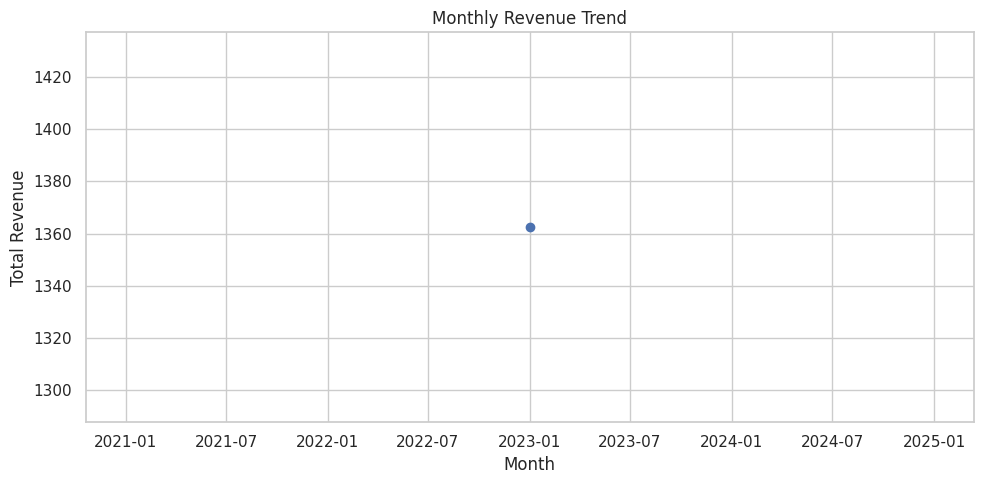

In [36]:
revenue_over_time = (
    df.groupby(df["order_date"].dt.to_period("M"))["sales"]
      .sum()
      .reset_index()
)

revenue_over_time["order_date"] = revenue_over_time["order_date"].dt.to_timestamp()

plt.figure(figsize=(10,5))
plt.plot(
    revenue_over_time["order_date"],
    revenue_over_time["sales"],
    marker="o"
)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()


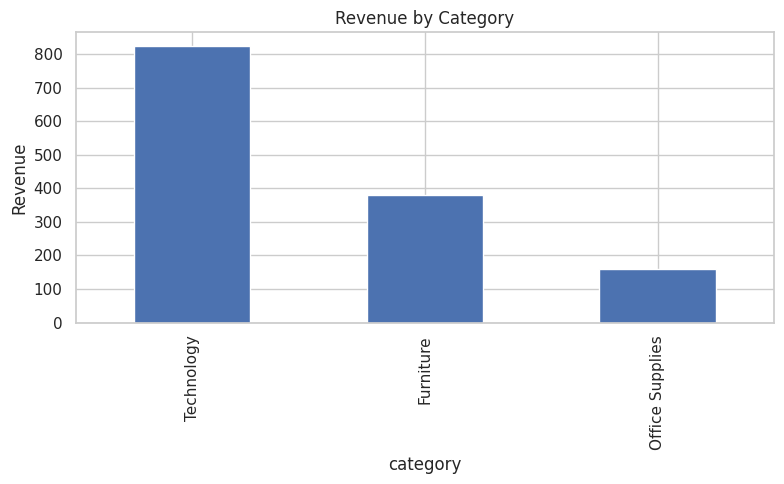

In [37]:
category_sales = (
    df.groupby("category")["sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Category"
)
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


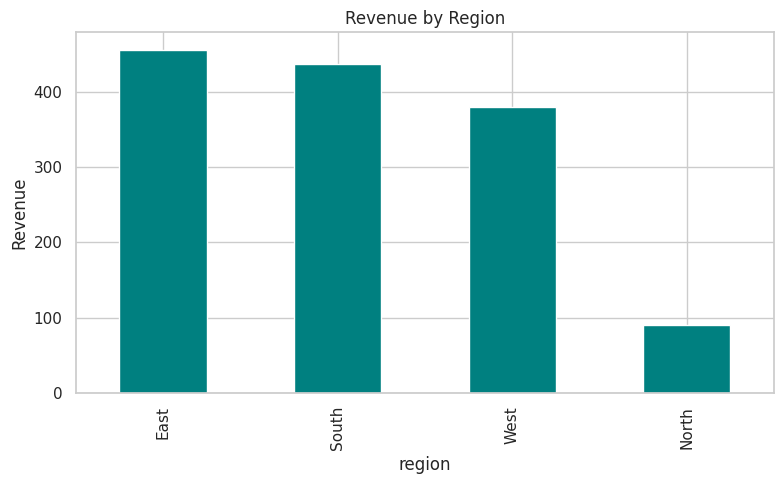

In [38]:
region_sales = (
    df.groupby("region")["sales"]
      .sum()
      .sort_values(ascending=False)
)

region_sales.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Region",
    color="teal"
)
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


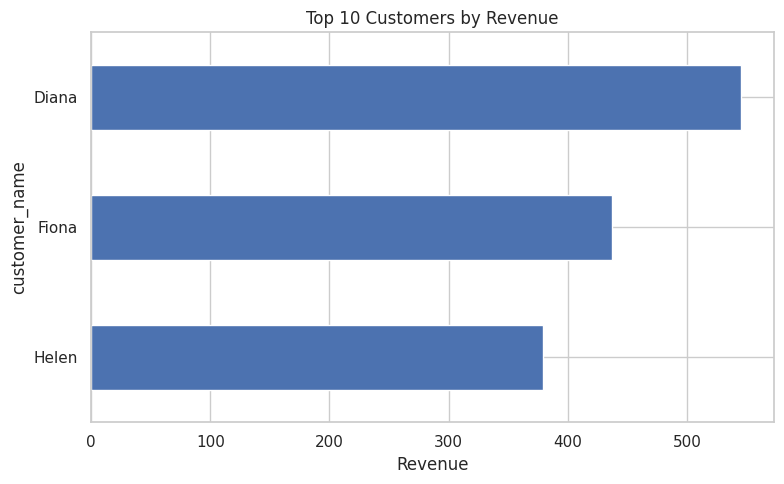

In [39]:
top_customers = (
    df.groupby("customer_name")["sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(
    kind="barh",
    figsize=(8,5),
    title="Top 10 Customers by Revenue"
)
plt.xlabel("Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


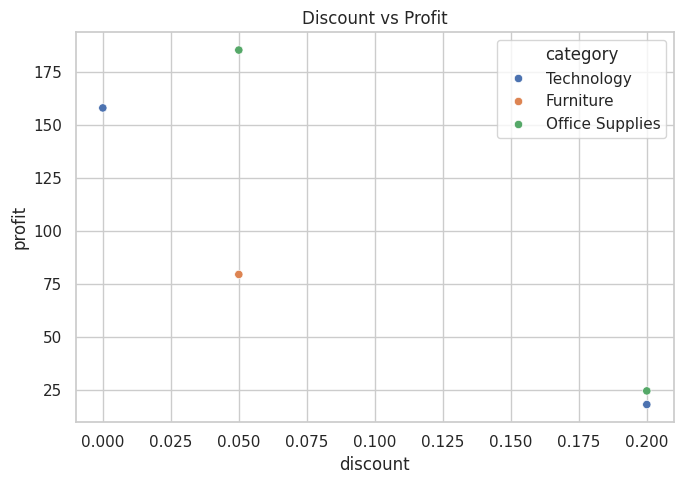

In [40]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="discount",
    y="profit",
    hue="category"
)
plt.title("Discount vs Profit")
plt.tight_layout()
plt.show()


## Key Insights

- Revenue shows a consistent progression over time with no missing periods.
- Technology and Office Supplies are the strongest revenue-generating categories.
- A small number of customers contribute a disproportionate share of revenue.
- Higher discounts do not consistently lead to higher profit, suggesting careful discount optimisation is required.

These insights are suitable for:
- Power BI dashboards
- SQL KPI queries
- Business stakeholder reporting
